In [68]:
import pandas as pd
import numpy as np
from pulp import *
import random
import matplotlib.pyplot as plt
import seaborn as sns
random.seed(1234)

##IMPORT DATA

**VARIABLE COST**

In [69]:
manufacturing_var_cost = pd.read_excel(r'/content/variable costs.xlsx', index_col=0)
manufacturing_var_cost

,USA,GERMANY,JAPAN,BRAZIL,INDIA
Variable Costs ($/Unit),,,,,
USA,12,12,12,12,12
GERMANY,13,13,13,13,13
JAPAN,10,10,10,10,10
BRAZIL,8,8,8,8,8
INDIA,5,5,5,5,5


**FREIGHT COST**

In [70]:
import_cost = pd.read_excel('/content/freight costs.xlsx', index_col=0)
import_cost

,USA,GERMANY,JAPAN,BRAZIL,INDIA
Freight Costs ($/Container),,,,,
USA,0,1750,1100,2300,1254
GERMANY,1905,0,1231,2892,1439
JAPAN,2200,3250,0,6230,2050
BRAZIL,2350,3150,4000,0,4250
INDIA,1950,2200,3500,4200,0


**TOTAL VARIABLE COST**

In [71]:
var_cost = (import_cost/1000) + manufacturing_var_cost
var_cost

,USA,GERMANY,JAPAN,BRAZIL,INDIA
Freight Costs ($/Container),,,,,
USA,12.000,13.75,13.100,14.300,13.254
GERMANY,14.905,13.00,14.231,15.892,14.439
JAPAN,12.200,13.25,10.000,16.230,12.050
BRAZIL,10.350,11.15,12.000,8.000,12.250
INDIA,6.950,7.20,8.500,9.200,5.000


Text(0.5, 0, 'country')

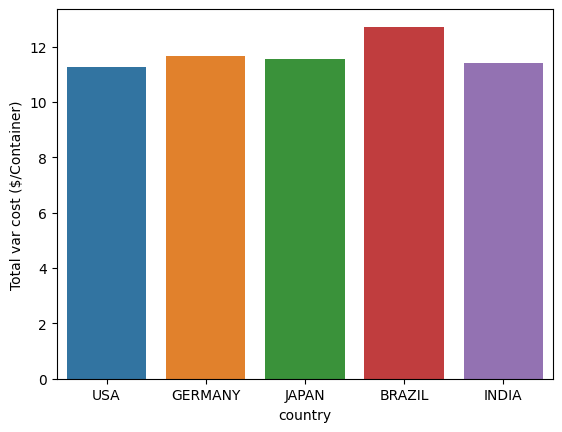

In [72]:
p =sns.barplot(data=var_cost, errorbar=None)
p.set_ylabel('Total var cost ($/Container)')
p.set_xlabel('country')

**FIXED COST**

In [73]:
fixed_cost = pd.read_excel('/content/fixed cost.xlsx', index_col=0)
fixed_cost

,LOW,HIGH
USA,6500,9500
GERMANY,4980,7270
JAPAN,6230,9100
BRAZIL,3230,4730
INDIA,2110,6160


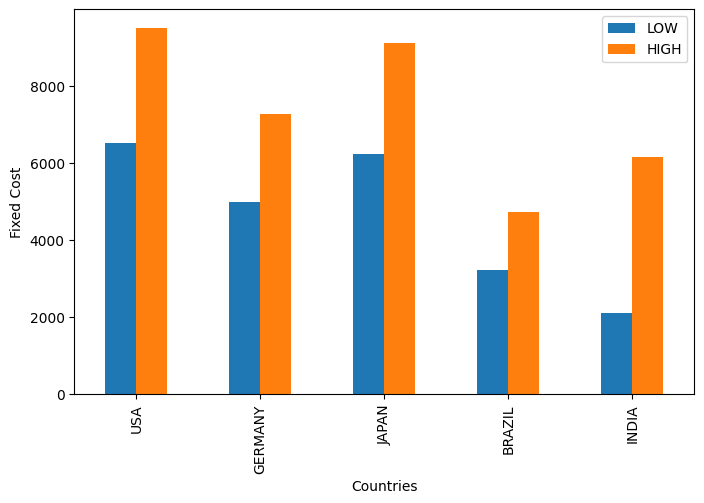

In [74]:
fixed_cost.plot(kind='bar', figsize=(8,5))

plt.ylabel('Fixed Cost')
plt.xlabel('Countries')
plt.show()

**PLANT CAPACITY**

In [75]:
#There are two types of plant: Low capacity & High Capacity
capacity= pd.read_excel('/content/capacity.xlsx', index_col=0)
capacity

,LOW,HIGH
Capacity (kUnits/month),,
USA,500,1500
GERMANY,500,1500
JAPAN,500,1500
BRAZIL,500,1500
INDIA,500,1500


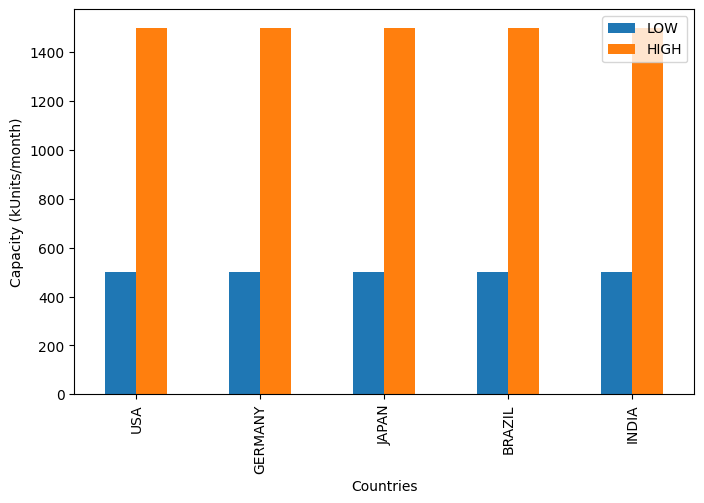

In [76]:
capacity.plot(kind='bar' ,figsize=(8,5))
plt.ylabel('Capacity (kUnits/month)')
plt.xlabel('Countries')
plt.show()

**DEMAND**

In [77]:
demand = pd.read_excel('/content/demand.xlsx', index_col=0)
demand

,Demand
(Units/month),
USA,2800000
GERMANY,90000
JAPAN,1700000
BRAZIL,145000
INDIA,160000


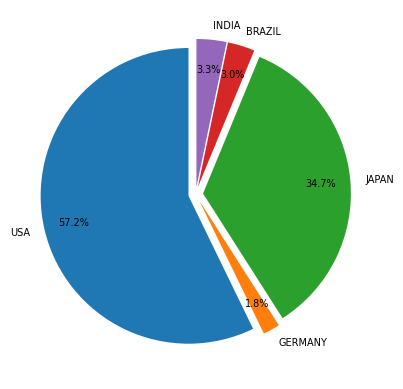

In [78]:
plt.pie(
    demand['Demand'],
    labels=demand.index,
    autopct='%1.1f%%',
    startangle=90,
    explode=[0.05]*len(demand),
    textprops={'fontsize':7},
    pctdistance=0.8,
    labeldistance=1.1
)
plt.show()

**INITIAL SOLUTION**

In [79]:
# Define Decision Variables
loc = ['USA', 'GERMANY', 'JAPAN', 'BRAZIL', 'INDIA']
size = ['LOW', 'HIGH']
plant_name = [(i,s) for s in size for i in loc]
prod_routes = [(i,j) for i in loc for j in loc]

# Initialize Class
model = LpProblem("Capacitated Plant Location Model", LpMinimize)


# Create Decision Variables
x = LpVariable.dicts("production_", prod_routes,
                     lowBound=0, upBound=None, cat='Integer')
y = LpVariable.dicts("plant_",
                     plant_name, cat='Binary')

# Define Objective Function
model += (lpSum([fixed_cost.loc[i,s] * y[(i,s)] * 1000 for s in size for i in loc])
          + lpSum([var_cost.loc[i,j] * x[(i,j)]   for i in loc for j in loc]))

# Add Constraints
for j in loc:
    model += lpSum([x[(i, j)] for i in loc]) == demand.loc[j,'Demand']
for i in loc:
    model += lpSum([x[(i, j)] for j in loc]) <= lpSum([capacity.loc[i,s]*y[(i,s)] * 1000
                                                       for s in size])

# Solve Model
model.solve()
print("Status: {}".format(LpStatus[model.status]))
print("Total Costs: {:,} ($/Month)".format(int(value(model.objective))))

# Results
df_bool = pd.DataFrame(data = [y[plant_name[i]].varValue for i in range(len(plant_name))], index = [i + '-' + s for s in size for i in loc],
                        columns = ['Plant Opening'])
df_bool

Status: Optimal
Total Costs: 65,118,000 ($/Month)


/usr/local/lib/python3.12/dist-packages/pulp/pulp.py:1706: UserWarning: Spaces are not permitted in the name. Converted to '_'
  warnings.warn("Spaces are not permitted in the name. Converted to '_'")


,Plant Opening
USA-LOW,0.0
GERMANY-LOW,0.0
JAPAN-LOW,0.0
BRAZIL-LOW,0.0
INDIA-LOW,1.0
USA-HIGH,0.0
GERMANY-HIGH,0.0
JAPAN-HIGH,1.0
BRAZIL-HIGH,1.0
INDIA-HIGH,1.0


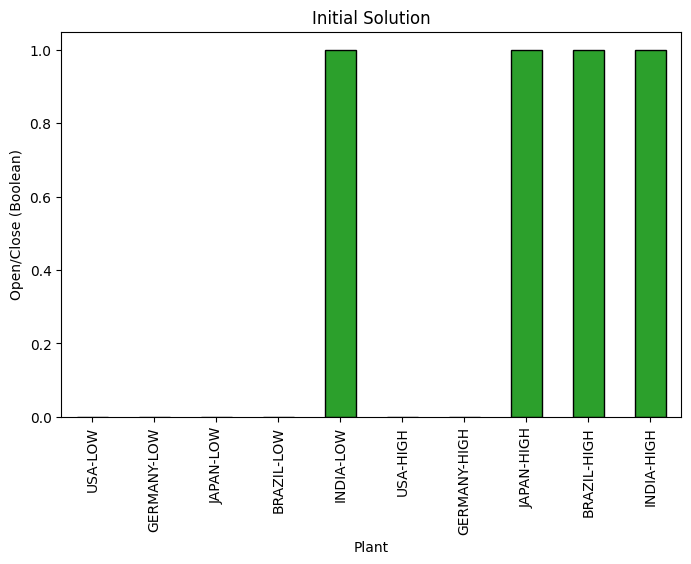

In [80]:
# Plant Opening - PLOT
cap_plot = capacity.copy()

ax = df_bool.astype(int).plot.bar(figsize=(8, 5), edgecolor='black', color = 'tab:green', y='Plant Opening', legend= False)
plt.xlabel('Plant')
plt.ylabel('Open/Close (Boolean)')
plt.title('Initial Solution')
plt.show()

##OPTIMIZATION MODEL

# Optimization Model Formulation

###**Decision Variables**

**1. Plant Opening Decision**

Variable: $y_{i,s}$ (Binary)

Indicates whether a plant of capacity size $s$ (Low/High) should be setup at location $i$.

$$y_{i,s} = \begin{cases} 1 & \text{if plant } i \text{ of size } s \text{ is opened} \\ 0 & \text{otherwise} \end{cases}$$

**2. Production & Distribution Decision**

Variable: $x_{i,j}$

Represents the quantity of units shipped from production location $i$ to market $j$.

$$x_{i,j} \geq 0 \quad \forall i, j$$

---

###**Objective Function**

Minimize total cost

$$\min Z = \sum_{i}\sum_{s} \text{FixedCost}_{i,s} \cdot y_{i,s} + \sum_{i}\sum_{j} \text{VariableCost}_{i,j} \cdot x_{i,j}$$


---

###**Constraints**

**Supply Capacity Constraint**

The total shipment from any plant cannot exceed its established capacity.

$$\sum_{j} x_{i,j} \leq \sum_{s} \text{Capacity}_{i,s} \cdot y_{i,s} \quad \forall i$$

**Demand Satisfaction Constraint**

Each market $j$ must receive exactly the quantity demanded.

$$\sum_{i} x_{i,j} = \text{Demand}_j \quad \forall j$$








In [81]:
def optimization_model(fixed_costs, var_cost, demand, demand_col, cap):
    '''Build the optimization based on input parameters'''
    # Define Decision Variables
    loc = ['USA', 'GERMANY', 'JAPAN', 'BRAZIL', 'INDIA']
    size = ['LOW', 'HIGH']
    plant_name = [(i,s) for s in size for i in loc]
    prod_routes = [(i,j) for i in loc for j in loc]

    # Initialize optimization model
    model = LpProblem("Capacitated Plant Location Model", LpMinimize)

    # Create Decision Variables
    x = LpVariable.dicts("production route(from, to):", prod_routes,
                         lowBound=0, upBound=None, cat='continuous')
    y = LpVariable.dicts("plant setup",
                         plant_name, cat='Binary')

    # Define Objective Function
    model += (lpSum([fixed_costs.loc[i,s] * y[(i,s)] * 1000 for s in size for i in loc])
              + lpSum([var_cost.loc[i,j] * x[(i,j)]   for i in loc for j in loc]))

    # Add Constraints
    for j in loc:
        model += lpSum([x[(i, j)] for i in loc]) == demand.loc[j,demand_col] #demand constraint
    for i in loc:
        model += lpSum([x[(i, j)] for j in loc]) <= lpSum([cap.loc[i,s]*y[(i,s)] * 1000 for s in size]) #suuply constraint
    # Solve Model
    model.solve()

    # Results
    status_out = LpStatus[model.status]
    objective_out  = pulp.value(model.objective)
    plant_bool = [y[plant_name[i]].varValue for i in range(len(plant_name))]
    fix = sum([fixed_costs.loc[i,s] * y[(i,s)].varValue * 1000 for s in size for i in loc])
    var = sum([var_cost.loc[i,j] * x[(i,j)].varValue for i in loc for j in loc])
    plant_routes = [x[prod_routes[i]].varValue for i in range(len(prod_routes))]
    return status_out, objective_out, y, x, fix, var

In [82]:
# Monte Carlo simulation approach

'''
This whole code block performs a Monte Carlo simulation of demand uncertainty by generating 50 random demand scenarios for each market from a Normal Distribution with:

Mean=Original Demand
Standard Deviation=CV×Demand
and then replacing any negative simulated demand with zero.
'''

N = 50 #generate 50 demand scenarios
df_demand = pd.DataFrame({'scenario': np.array(range(1, N + 1))})
data = demand.reset_index()
# Demand
CV = 0.5
markets = data['(Units/month)'].values
for col, value in zip(markets, data['Demand'].values):
    sigma = CV * value
    df_demand[col] = np.random.normal(value, sigma, N)
    df_demand[col] = df_demand[col].apply(lambda t: t if t>=0 else 0)

# Add Initial Scenario
COLS = ['scenario'] + list(demand.index)
VALS = [0] + list(demand['Demand'].values)
df_init = pd.DataFrame(dict(zip(COLS, VALS)), index = [0])

df_demand.astype(int).head()

,scenario,USA,GERMANY,JAPAN,BRAZIL,INDIA
0,1,4501793,47012,1518336,100753,40413
1,2,3707616,48612,1119114,139838,112623
2,3,6866710,112221,0,165383,158504
3,4,2260272,94660,1279336,64869,116940
4,5,4999718,125666,2180731,273870,139506


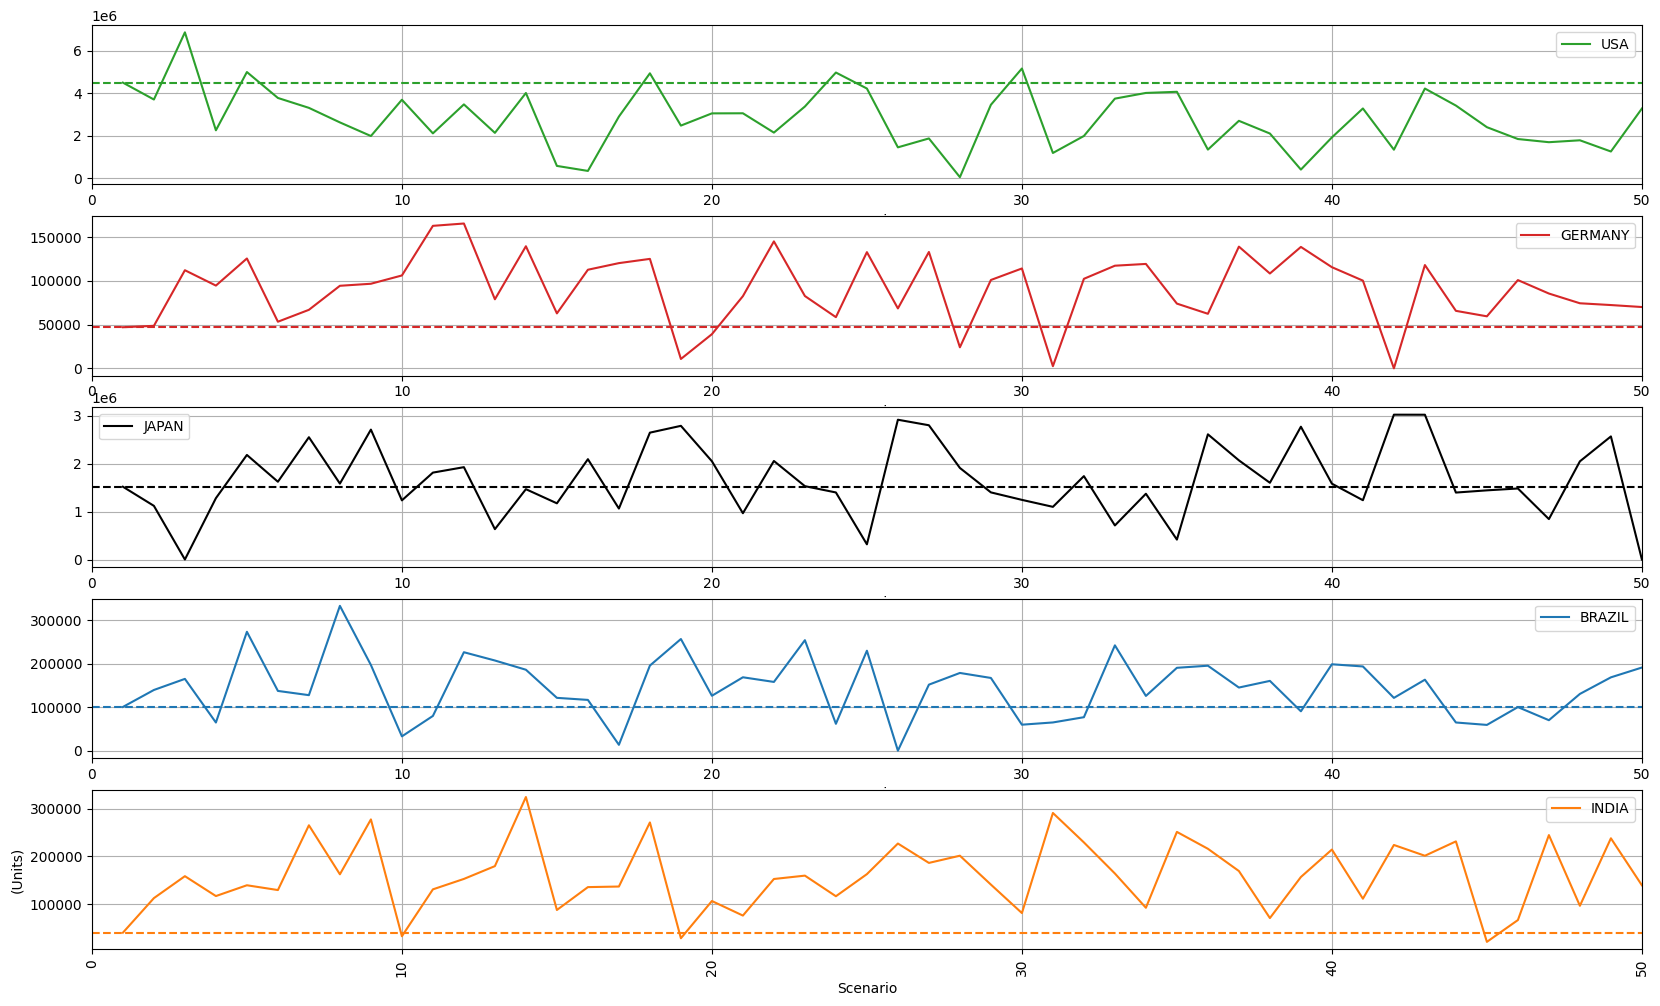

In [83]:
# Plot
figure, axes = plt.subplots(len(markets), 1)
colors = ['tab:green', 'tab:red', 'black', 'tab:blue', 'tab:orange']
for i in range(len(markets)):
    df_demand.plot(figsize=(20, 12), xlim=[0,N], x='scenario', y=markets[i], ax=axes[i], grid = True, color = colors[i])
    axes[i].axhline(df_demand[markets[i]].values[0], color=colors[i], linestyle="--")
plt.xlabel('Scenario')
plt.ylabel('(Units)')
plt.xticks(rotation=90)
plt.show()

In [84]:
# Record results per scenario
list_scenario, list_status, list_results, list_totald, list_fixcost, list_varcost, shipment_results = [], [], [], [], [], [], []

# Initial Scenario
status_out, objective_out, y, x, fix, var = optimization_model(fixed_cost, var_cost, demand, 'Demand', capacity)

# Add results
list_scenario.append('INITIAL')
total_demand = demand['Demand'].sum()
list_totald.append(total_demand)
list_status.append(status_out)
list_results.append(objective_out)
list_fixcost.append(fix)
list_varcost.append(var)

# Dataframe to record the solutions
df_bool = pd.DataFrame(data = [y[plant_name[i]].varValue for i in range(len(plant_name))], index = [i + '-' + s for s in size for i in loc],
                        columns = ['INITIAL'])
df_bool.head()

/usr/local/lib/python3.12/dist-packages/pulp/pulp.py:1706: UserWarning: Spaces are not permitted in the name. Converted to '_'
  warnings.warn("Spaces are not permitted in the name. Converted to '_'")


,INITIAL
USA-LOW,0.0
GERMANY-LOW,0.0
JAPAN-LOW,0.0
BRAZIL-LOW,0.0
INDIA-LOW,1.0


In [85]:
# Simulate all scenarios
demand_var = df_demand.drop(['scenario'], axis = 1).T

# Loop
for i in range(1, 50): # 0 is the initial scenario
    # Calculations
    status_out, objective_out, y, x, fix, var = optimization_model(fixed_cost, var_cost, demand_var, i, capacity)

    # Append results
    list_status.append(status_out)
    list_results.append(objective_out)
    df_bool[i] = [y[plant_name[i]].varValue for i in range(len(plant_name))]
    list_fixcost.append(fix)
    list_varcost.append(var)
    total_demand = demand_var[i].sum()
    list_totald.append(total_demand)
    list_scenario.append(i)

    #shippment quantitites
    for p in loc:
      for m in loc:
        shipment_results.append({
            'scenario': i,
            'from': p,
            'to':m,
            'quantity': x[(p,m)].varValue})

# Final Results
#For plant opening decisions
df_bool = df_bool.astype(int)



# plant open df
df_bool.head()

#shippment df
df_shipments= pd.DataFrame(shipment_results)

#cost df
df_cost= pd.DataFrame({
    'Scenario': list_scenario,
    'Status': list_status,
    'Total Demand': list_totald,
    'Total Cost': list_results
})

print(df_bool.head())
print(df_shipments.head())
print(df_cost.head())

/usr/local/lib/python3.12/dist-packages/pulp/pulp.py:1706: UserWarning: Spaces are not permitted in the name. Converted to '_'
  warnings.warn("Spaces are not permitted in the name. Converted to '_'")
/usr/local/lib/python3.12/dist-packages/pulp/pulp.py:1706: UserWarning: Spaces are not permitted in the name. Converted to '_'
  warnings.warn("Spaces are not permitted in the name. Converted to '_'")
/usr/local/lib/python3.12/dist-packages/pulp/pulp.py:1706: UserWarning: Spaces are not permitted in the name. Converted to '_'
  warnings.warn("Spaces are not permitted in the name. Converted to '_'")
/usr/local/lib/python3.12/dist-packages/pulp/pulp.py:1706: UserWarning: Spaces are not permitted in the name. Converted to '_'
  warnings.warn("Spaces are not permitted in the name. Converted to '_'")
/usr/local/lib/python3.12/dist-packages/pulp/pulp.py:1706: UserWarning: Spaces are not permitted in the name. Converted to '_'
  warnings.warn("Spaces are not permitted in the name. Converted to '

             INITIAL  1  2  3  4  5  6  7  8  9  ...  40  41  42  43  44  45  \
USA-LOW            0  0  0  0  0  0  0  0  0  0  ...   0   0   0   0   0   0   
GERMANY-LOW        0  0  1  0  0  1  0  0  0  0  ...   0   0   0   0   0   0   
JAPAN-LOW          0  0  0  0  0  0  0  0  0  0  ...   0   0   0   0   0   0   
BRAZIL-LOW         0  1  1  1  0  1  0  0  1  1  ...   0   0   0   1   1   1   
INDIA-LOW          1  1  1  1  1  1  1  1  1  1  ...   1   1   1   1   1   1   

             46  47  48  49  
USA-LOW       0   0   0   0  
GERMANY-LOW   0   0   0   0  
JAPAN-LOW     0   0   0   0  
BRAZIL-LOW    0   0   0   1  
INDIA-LOW     0   0   0   1  

[5 rows x 50 columns]
   scenario from       to  quantity
0         1  USA      USA       0.0
1         1  USA  GERMANY       0.0
2         1  USA    JAPAN       0.0
3         1  USA   BRAZIL       0.0
4         1  USA    INDIA       0.0
  Scenario   Status  Total Demand    Total Cost
0  INITIAL  Optimal  4.895000e+06  6.511800e+07
1   

In [86]:
#Total quantity shipped from Country i to market j

df_shipments[df_shipments['quantity']>0]

,scenario,from,to,quantity
10,1,JAPAN,USA,8.690953e+03
12,1,JAPAN,JAPAN,1.119115e+06
15,1,BRAZIL,USA,1.860162e+06
18,1,BRAZIL,BRAZIL,1.398383e+05
20,1,INDIA,USA,1.838764e+06
...,...,...,...,...
1215,49,BRAZIL,USA,1.491901e+06
1218,49,BRAZIL,BRAZIL,1.915219e+05
1220,49,INDIA,USA,1.790429e+06
1221,49,INDIA,GERMANY,7.013433e+04


In [87]:
#Total cost for each scenario
df_cost['Total Cost'] = df_cost['Total Cost'].round(0).astype(int)
df_cost['Total Demand'] = df_cost['Total Demand'].round(0).astype(int)

df_cost['Total Cost'] = df_cost['Total Cost'].map('{:,.0f}'.format)
df_cost['Total Demand'] = df_cost['Total Demand'].map('{:,.0f}'.format)

df_cost.head(10)

,Scenario,Status,Total Demand,Total Cost
0,INITIAL,Optimal,"4,895,000","65,118,000"
1,1,Optimal,"5,127,806","70,691,094"
2,2,Optimal,"7,302,820","114,312,012"
3,3,Optimal,"3,816,079","50,552,579"
4,4,Optimal,"7,719,493","117,857,705"
5,5,Optimal,"5,723,377","82,479,530"
6,6,Optimal,"6,325,410","91,897,717"
7,7,Optimal,"4,804,391","63,552,167"
8,8,Optimal,"5,271,598","73,460,320"
9,9,Optimal,"5,102,323","70,791,975"


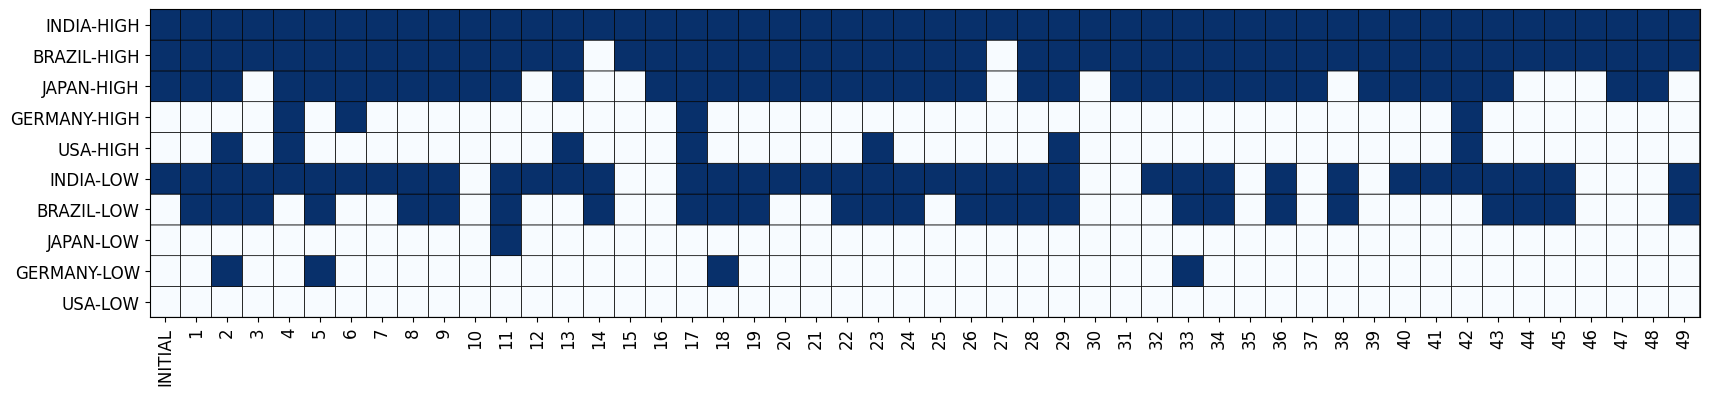

In [88]:
# Plot the plant opening Grid
plt.figure(figsize = (20,4))
plt.pcolor( df_bool, cmap = 'Blues', edgecolors='k', linewidths=0.5)
plt.xticks([i + 0.5 for i in range(df_bool.shape[1])], df_bool.columns, rotation = 90, fontsize=12)
plt.yticks([i + 0.5 for i in range(df_bool.shape[0])], df_bool.index, fontsize=12)
plt.show()

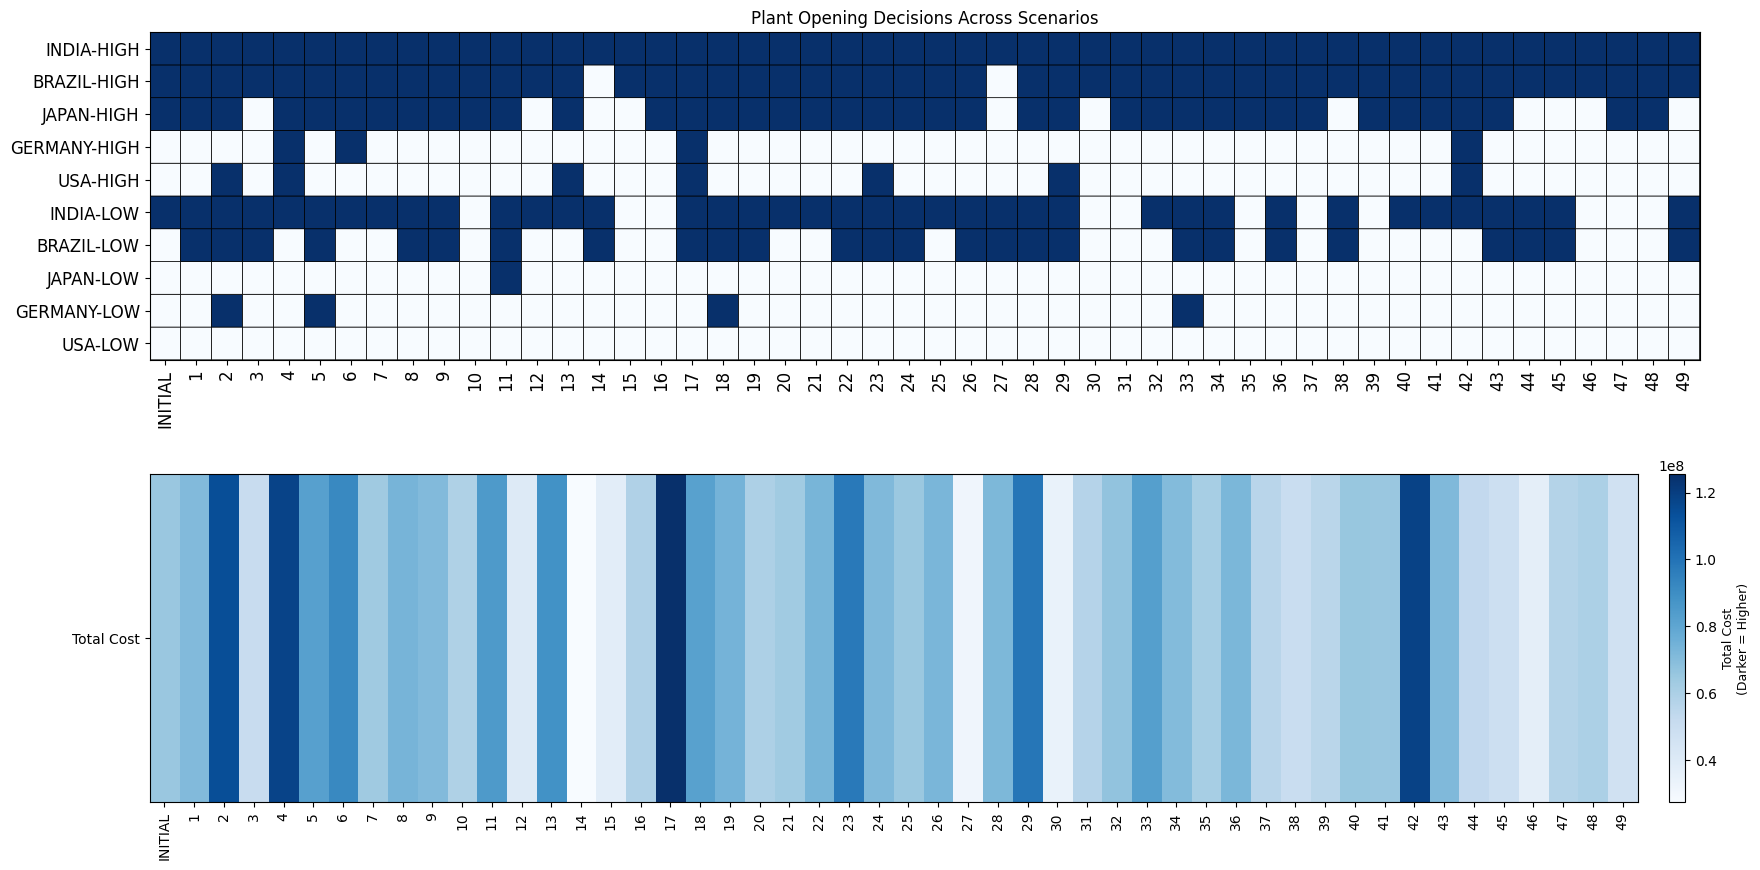

In [89]:
from matplotlib.colors import Normalize

# Convert Total Cost to numeric

df_cost['Total Cost'] = (df_cost['Total Cost'].astype(str).str.replace(',', '', regex=False).astype(float))

# Get costs in same order as df_bool columns

cost_values = []

for scenario in df_bool.columns:
    cost = df_cost.loc[
        df_cost['Scenario'].astype(str) == str(scenario),'Total Cost'].iloc[0]
    cost_values.append(cost)

cost_array = np.array(cost_values, dtype=float).reshape(1, -1)

# Normalize cost colors

norm = Normalize(vmin=min(cost_values), vmax=max(cost_values))

#Creating figure

fig = plt.figure(figsize=(20, 10))

gs = fig.add_gridspec(2, 1,height_ratios=[1, 1],hspace=0.35)

# Plant opening heatmap

ax1 = fig.add_subplot(gs[0])

im1 = ax1.pcolor(df_bool,cmap='Blues',edgecolors='k',linewidths=0.5)
ax1.pcolor( df_bool, cmap = 'Blues', edgecolors='k', linewidths=0.5)   #
ax1.set_xticks([i + 0.5 for i in range(df_bool.shape[1])], df_bool.columns, rotation = 90, fontsize=12)
ax1.set_yticks([i + 0.5 for i in range(df_bool.shape[0])], df_bool.index, fontsize=12)

ax1.set_title('Plant Opening Decisions Across Scenarios')

# Cost hue strip
ax2 = fig.add_subplot(gs[1])

im2 = ax2.imshow(cost_array, aspect='auto',cmap='Blues',norm=norm)
ax2.set_yticks([0], ['Total Cost'])
ax2.set_xticks(np.arange(len(df_bool.columns)))
ax2.set_xticklabels(df_bool.columns,rotation=90)

# Adding colorbar for cost strip
cbar2 = plt.colorbar(im2, ax=ax2, pad=0.02, fraction=0.02)
cbar2.set_label('Total Cost\n(Darker = Higher)', fontsize=9)

plt.show()


##ANALYSIS



In [90]:
df_cost['Total Demand'] = pd.to_numeric(df_cost['Total Demand'].str.replace(',', ''),errors='coerce')

**NETWORK COST ANALYSIS**

In [91]:
def to_cr(x):
    return f"₹ {x/1e7:,.2f} Cr"

print('Average Network Cost             :', to_cr(df_cost['Total Cost'].mean()))
print('Median Network Cost              :', to_cr(df_cost['Total Cost'].median()))
print('Best-Case Network Cost           :', to_cr(df_cost['Total Cost'].min()))
print('Worst-Case Network Cost          :', to_cr(df_cost['Total Cost'].max()))
print('Worst Case Premium               :', to_cr(df_cost['Total Cost'].max() - df_cost['Total Cost'].mean()))
print('Cost Volatility (Std. Dev.)      :', to_cr(df_cost['Total Cost'].std()))
print('Cost Spread                      :', to_cr(df_cost['Total Cost'].min()),"-", to_cr(df_cost['Total Cost'].max()))
print('Coefficient of Variation (CV)    :', f"{100 * df_cost['Total Cost'].std()/df_cost['Total Cost'].mean():.2f}%")
print('Optimal Network Stability        :', round((df_bool.T.value_counts().max()/ len(df_bool.columns)) * 100, 2),'%')
print('Demand-Cost Correlation          :', df_cost['Total Demand'].corr(df_cost['Total Cost']))
cost_change = (
    df_cost['Total Cost'].max()
    -
    df_cost['Total Cost'].min()
) / df_cost['Total Cost'].min()

demand_change = (
    df_cost['Total Demand'].max()
    -
    df_cost['Total Demand'].min()
) / df_cost['Total Demand'].min()

elasticity = cost_change / demand_change

print('Cost Elasticity                  :',round(elasticity,2))

Average Network Cost             : ₹ 6.82 Cr
Median Network Cost              : ₹ 6.54 Cr
Best-Case Network Cost           : ₹ 2.74 Cr
Worst-Case Network Cost          : ₹ 12.54 Cr
Worst Case Premium               : ₹ 5.72 Cr
Cost Volatility (Std. Dev.)      : ₹ 2.20 Cr
Cost Spread                      : ₹ 2.74 Cr - ₹ 12.54 Cr
Coefficient of Variation (CV)    : 32.31%
Optimal Network Stability        : 22.0 %
Demand-Cost Correlation          : 0.9945202335598033
Cost Elasticity                  : 1.18


**PLANT DECISION VOLATILITY ANALYSIS**

In [92]:
plant_volatility = (df_bool.mean(axis=1).apply(lambda x: min(x, 1-x)).sort_values(ascending=False))
print("Facilities that are responsible for the network changing under uncertainty")
plant_volatility

Facilities that are responsible for the network changing under uncertainty


,0
BRAZIL-LOW,0.48
INDIA-LOW,0.22
JAPAN-HIGH,0.22
USA-HIGH,0.14
GERMANY-HIGH,0.08
GERMANY-LOW,0.08
BRAZIL-HIGH,0.04
JAPAN-LOW,0.02
USA-LOW,0.00
INDIA-HIGH,0.00


**UNIQUE NETWORKS**



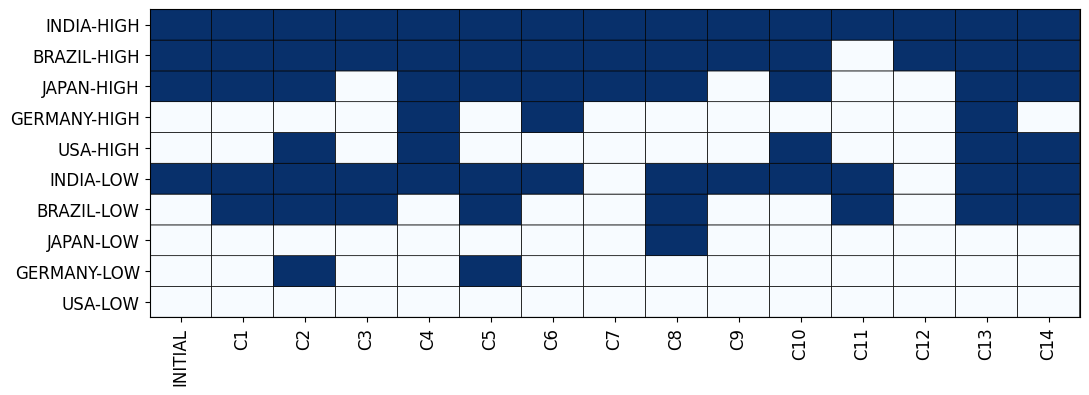

In [93]:
# Unique combinations
df_unique = df_bool.T.drop_duplicates().T
df_unique.columns = ['INITIAL'] + ['C' + str(i) for i in range(1, len(df_unique.columns))]

# Plot
plt.figure(figsize = (12,4))
plt.pcolor( df_unique, cmap = 'Blues', edgecolors='k', linewidths=0.5)
plt.xticks([i + 0.5 for i in range(df_unique.shape[1])], df_unique.columns, rotation = 90, fontsize=12)
plt.yticks([i + 0.5 for i in range(df_unique.shape[0])], df_unique.index, fontsize=12)
plt.show()

**PLANT SETUP FREQUENCY**

In [94]:
(df_bool.T.sum().sort_values(ascending=False)/50)*100

,0
INDIA-HIGH,100.0
BRAZIL-HIGH,96.0
INDIA-LOW,78.0
JAPAN-HIGH,78.0
BRAZIL-LOW,52.0
USA-HIGH,14.0
GERMANY-HIGH,8.0
GERMANY-LOW,8.0
JAPAN-LOW,2.0
USA-LOW,0.0


**MOST FREQUENT NETWORK CONFIGURATION**

In [95]:
df_bool.T.value_counts()

USA-LOW  GERMANY-LOW  JAPAN-LOW  BRAZIL-LOW  INDIA-LOW  USA-HIGH  GERMANY-HIGH  JAPAN-HIGH  BRAZIL-HIGH  INDIA-HIGH
0        0            0          1           1          0         0             1           1            1             11
                                 0           1          0         0             1           1            1              8
                                             0          0         0             1           1            1              8
                                 1           1          0         0             0           1            1              5
         1            0          1           1          0         0             1           1            1              3
         0            0          0           0          0         0             0           1            1              3
                                             1          1         1             1           1            1              2
                                 1           1          1         0             1           1            1              2
                                                        0         0             0           0            1              2
                                 0           1          0         0             0           1            1              1
                                                                  1             1           1            1              1
                                                        1         0             1           1            1              1
                                 1           1          1         1             1           1            1              1
                      1          1           1          0         0             1           1            1              1
         1            0          1           1          1         0             1           1            1              1
Name: count, dtype: int64

**STUDYING THE MOST FREQUENT NETWORK CONFIGURATION**

In [96]:
# Most frequent network configuration
dominant_solution = df_bool.T.value_counts().index[0]

mask = (df_bool.T == dominant_solution).all(axis=1)

df_fre_sol_cost = df_cost[
    df_cost['Scenario'].isin(
        df_bool.T.index[mask]
    )
]

In [97]:
print('Frequency of Optimal Network Design (%) :', round(mask.mean()*100,2))
print('Average Cost                            :', to_cr(df_fre_sol_cost['Total Cost'].mean()))
print('Cost Range                              :', to_cr(df_fre_sol_cost['Total Cost'].min()),'-', to_cr(df_fre_sol_cost['Total Cost'].max()))
print('Cost Stability of the Dominant Design   :', round(100*(df_fre_sol_cost['Total Cost'].std()/df_fre_sol_cost['Total Cost'].mean()),2))
print('Cost Difference from Overall Average    :', to_cr(df_fre_sol_cost['Total Cost'].mean() - df_cost['Total Cost'].mean()))
print('Demand Range Supported                  :', df_fre_sol_cost['Total Demand'].min(),'Units -',df_fre_sol_cost['Total Demand'].max(),'Units')
print('Average Demand Served :',df_fre_sol_cost['Total Demand'].mean())

Frequency of Optimal Network Design (%) : 22.0
Average Cost                            : ₹ 7.20 Cr
Cost Range                              : ₹ 7.03 Cr - ₹ 7.40 Cr
Cost Stability of the Dominant Design   : 1.71
Cost Difference from Overall Average    : ₹ 0.37 Cr
Demand Range Supported                  : 5001928 Units - 5405026 Units
Average Demand Served : 5198191.545454546


**MOST FREQUENT vs SECOND MOST FREQUENT NETWORK CONFIGURATION**

In [98]:
network_freq = df_bool.T.value_counts()

# Top 2 configurations
design_1 = network_freq.index[0]
design_2 = network_freq.index[1]

# Scenarios belonging to each configuration
mask_1 = (df_bool.T == design_1).all(axis=1)
mask_2 = (df_bool.T == design_2).all(axis=1)

df_design_1 = df_cost[df_cost['Scenario'].isin(df_bool.T.index[mask_1])]
df_design_2 = df_cost[df_cost['Scenario'].isin(df_bool.T.index[mask_2])]


config_comparison = pd.DataFrame({
    'Plant': df_bool.index,
    'Most Frequent Design': design_1,
    'Second Most Frequent Design': design_2
})
print(config_comparison)

          Plant  Most Frequent Design  Second Most Frequent Design
0       USA-LOW                     0                            0
1   GERMANY-LOW                     0                            0
2     JAPAN-LOW                     0                            0
3    BRAZIL-LOW                     1                            0
4     INDIA-LOW                     1                            1
5      USA-HIGH                     0                            0
6  GERMANY-HIGH                     0                            0
7    JAPAN-HIGH                     1                            1
8   BRAZIL-HIGH                     1                            1
9    INDIA-HIGH                     1                            1


In [99]:
# Comparison table
comparison = pd.DataFrame({

    'Metric': [
        'Frequency (%)',
        'Average Cost',
        'Cost CV (%)',
        'Minimum Demand',
        'Maximum Demand',
        'Demand Coverage Width'
    ],

    'Most Frequent Design': [
        round(100 * (len(df_design_1) / len(df_cost)), 2),
        round(df_design_1['Total Cost'].mean(), 2),
        round(100 * (df_design_1['Total Cost'].std() / df_design_1['Total Cost'].mean()),2),
        df_design_1['Total Demand'].min(),
        df_design_1['Total Demand'].max(),
        df_design_1['Total Demand'].max()-df_design_1['Total Demand'].min()],

    'Second Most Frequent Design': [

        round(100 * len(df_design_2) / len(df_cost), 2),
        round(df_design_2['Total Cost'].mean(), 2),
        round(100 * df_design_2['Total Cost'].std()/df_design_2['Total Cost'].mean(),2),
        df_design_2['Total Demand'].min(),
        df_design_2['Total Demand'].max(),
        df_design_2['Total Demand'].max() -  df_design_2['Total Demand'].min()]
})

print(comparison)




                  Metric  Most Frequent Design  Second Most Frequent Design
0          Frequency (%)                 22.00                        16.00
1           Average Cost           71982036.45                  64284688.12
2            Cost CV (%)                  1.71                         3.56
3         Minimum Demand            5001928.00                   4353206.00
4         Maximum Demand            5405026.00                   4983606.00
5  Demand Coverage Width             403098.00                    630400.00


**DEMAND - COST RELATIONSHIP**

Correlation between Demand and Cost: 0.9945
Marginal Cost per unit demand: 16.35


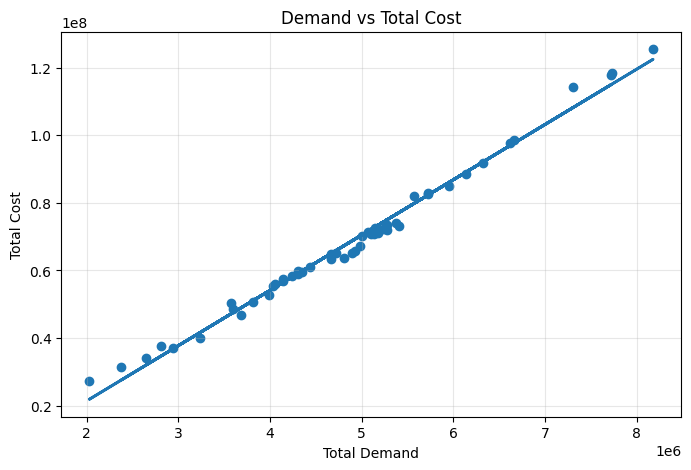

In [100]:
corr = df_cost['Total Demand'].corr(df_cost['Total Cost'])

# Linear Regression
slope, intercept = np.polyfit(
    df_cost['Total Demand'],
    df_cost['Total Cost'],
    1
)

print(f'Correlation between Demand and Cost: {corr:.4f}')
print(f'Marginal Cost per unit demand: {slope:.2f}')

# Scatter Plot + Trend Line
plt.figure(figsize=(8,5))

plt.scatter(
    df_cost['Total Demand'],
    df_cost['Total Cost']
)

plt.plot(
    df_cost['Total Demand'],
    slope * df_cost['Total Demand'] + intercept,
    linewidth=2
)

plt.xlabel('Total Demand')
plt.ylabel('Total Cost')
plt.title('Demand vs Total Cost')
plt.grid(alpha=0.3)

plt.show()

In [101]:
#Cost Elasticity with respect to Demand

# Percentage Cost Change
cost_change = (
    df_cost['Total Cost'].max()
    - df_cost['Total Cost'].min()
) / df_cost['Total Cost'].min()

# Percentage Demand Change
demand_change = (
    df_cost['Total Demand'].max()
    - df_cost['Total Demand'].min()
) / df_cost['Total Demand'].min()

elasticity = cost_change / demand_change

print(f'Cost Elasticity with respect to Demand: {elasticity:.2f}')

Cost Elasticity with respect to Demand: 1.18


In [102]:
cost_per_unit = (df_cost['Total Cost']/ df_cost['Total Demand'])

print('Average Cost per Unit Demand    :',round(cost_per_unit.mean(),2))
print('Minimum Cost per Unit Demand    :',round(cost_per_unit.min(),2))
print('Maximum Cost per Unit Demand    :',round(cost_per_unit.max(),2))

Average Cost per Unit Demand    : 13.88
Minimum Cost per Unit Demand    : 12.31
Maximum Cost per Unit Demand    : 15.65


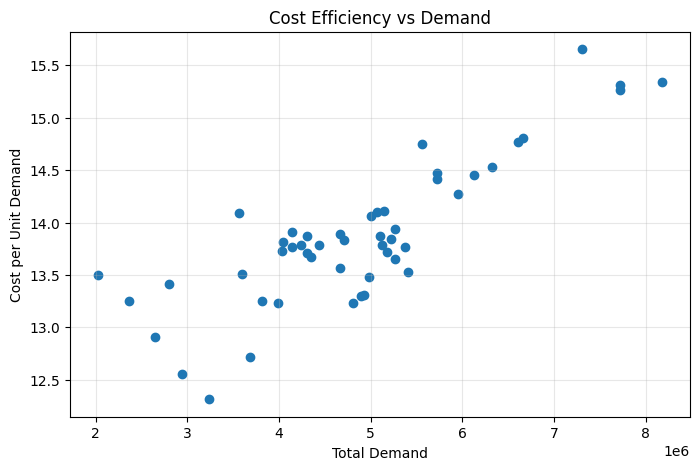

In [103]:
#PLOT: Cost Efficiency vs Demand

plt.figure(figsize=(8,5))

plt.scatter(
    df_cost['Total Demand'],
    cost_per_unit
)

plt.xlabel('Total Demand')
plt.ylabel('Cost per Unit Demand')
plt.title('Cost Efficiency vs Demand')
plt.grid(alpha=0.3)

plt.show()

**SUMMARY : DEMAND-COST SENSITIVITY**

In [104]:
print(f'Correlation               : {corr:.3f}')
print(f'Marginal Cost             : {slope:.2f}')
print(f'Cost Elasticity           : {elasticity:.2f}')
print(f'Average Cost per Demand   : {cost_per_unit.mean():.2f}')
print(f'Min Cost per Demand       : {cost_per_unit.min():.2f}')
print(f'Max Cost per Demand       : {cost_per_unit.max():.2f}')

Correlation               : 0.995
Marginal Cost             : 16.35
Cost Elasticity           : 1.18
Average Cost per Demand   : 13.88
Min Cost per Demand       : 12.31
Max Cost per Demand       : 15.65
